In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [142]:
df=pd.read_csv("CrimesOnWomenData.csv")
df.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [143]:
df.describe()

,Unnamed: 0,Year,Rape,K&A,DD,AoW,AoM,DV,WT
count,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000
mean,367.500000,2011.149457,727.855978,1134.542120,215.692935,1579.115489,332.722826,2595.078804,28.744565
std,212.609188,6.053453,977.024945,1993.536828,424.927334,2463.962518,806.024551,4042.004953,79.999660
min,0.000000,2001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,183.750000,2006.000000,35.000000,24.750000,1.000000,34.000000,3.000000,13.000000,0.000000
50%,367.500000,2011.000000,348.500000,290.000000,29.000000,387.500000,31.000000,678.500000,0.000000
75%,551.250000,2016.000000,1069.000000,1216.000000,259.000000,2122.250000,277.500000,3545.000000,15.000000
max,735.000000,2021.000000,6337.000000,15381.000000,2524.000000,14853.000000,9422.000000,23278.000000,549.000000


In [144]:
df.isnull().sum()

Unnamed: 0    0
State         0
Year          0
Rape          0
K&A           0
DD            0
AoW           0
AoM           0
DV            0
WT            0
dtype: int64

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  736 non-null    int64 
 1   State       736 non-null    object
 2   Year        736 non-null    int64 
 3   Rape        736 non-null    int64 
 4   K&A         736 non-null    int64 
 5   DD          736 non-null    int64 
 6   AoW         736 non-null    int64 
 7   AoM         736 non-null    int64 
 8   DV          736 non-null    int64 
 9   WT          736 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 57.6+ KB


In [146]:
crime_cols = ['Rape', 'K&A', 'DD', 'AoW', 'AoM', 'DV', 'WT']
column_descriptions = {
    'Rape': 'Rape cases',
    'K&A': 'Kidnapping & Abduction',
    'DD': 'Dowry Deaths',
    'AoW': 'Assault on Women',
    'AoM': 'Assault on Modesty',
    'DV': 'Domestic Violence',
    'WT': 'Women Trafficking'
}

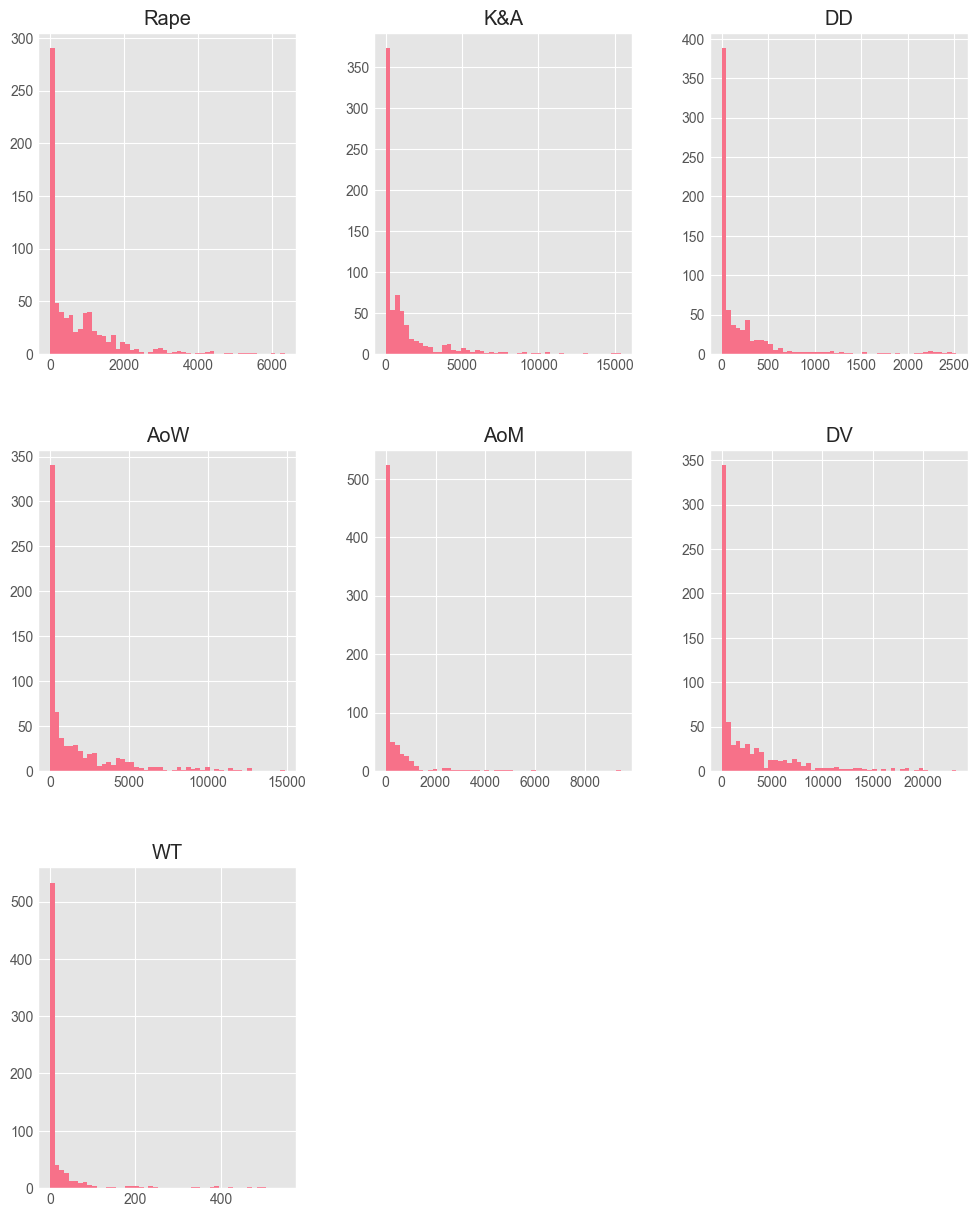

In [147]:
#write /plot histogram for numarical feature
df[crime_cols].hist(bins=50, figsize=(12,15))
plt.show()

In [148]:
df['Total_Crimes'] = df[crime_cols].sum(axis=1)

In [149]:
df['Average_Crime_Rate'] = df[crime_cols].mean(axis=1)

In [150]:
weights = {
    'Rape': 1.0,           # Most severe
    'K&A': 0.9,            # Very severe
    'DD': 0.95,            # Very severe (dowry-related)
    'AoW': 0.7,            # Moderate
    'AoM': 0.5,            # Less severe
    'DV': 0.8,             # Severe (affects families)
    'WT': 0.95             # Very severe (trafficking)
}

Correlation matrix of num features:


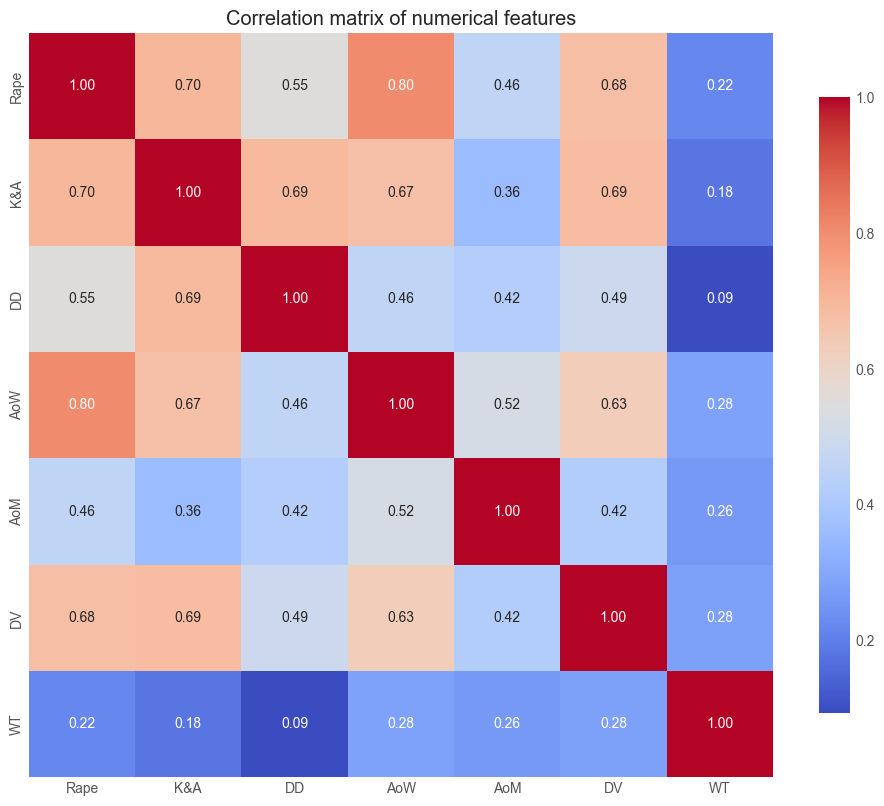

In [151]:
print("Correlation matrix of num features:")
plt.figure(figsize=(12,10))
corr_matrix = df[crime_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation matrix of numerical features")
plt.show()

In [152]:
for crime, weight in weights.items():
    print(f"    {crime}: {weight}")

    Rape: 1.0
    K&A: 0.9
    DD: 0.95
    AoW: 0.7
    AoM: 0.5
    DV: 0.8
    WT: 0.95


In [153]:

df['Safety_Score'] = sum(df[col] * weights[col] for col in crime_cols)
print(f"\n Safety_Score: Weighted sum emphasizing severe crimes")


 Safety_Score: Weighted sum emphasizing severe crimes


In [154]:
df. Safety_Score.info()

<class 'pandas.core.series.Series'>
RangeIndex: 736 entries, 0 to 735
Series name: Safety_Score
Non-Null Count  Dtype  
--------------  -----  
736 non-null    float64
dtypes: float64(1)
memory usage: 5.9 KB


In [155]:
df.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total_Crimes,Average_Crime_Rate,Safety_Score
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7,13669,1952.714286,10214.25
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0,180,25.714286,147.40
2,2,ASSAM,2001,817,1070,59,850,4,1248,0,4048,578.285714,3431.45
3,3,BIHAR,2001,888,518,859,562,21,1558,83,4489,641.285714,3899.40
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0,3964,566.285714,3166.00


In [156]:
df['Normalized_Safety_Score'] = df['Safety_Score'] / (df['Safety_Score'].max() + 1)
print(f" Normalized_Safety_Score: Scaled score between 0-1")

 Normalized_Safety_Score: Scaled score between 0-1


In [157]:
# Calculate trend (year-over-year change)
df_sorted = df.sort_values(['State', 'Year'])
df['Crime_Trend'] = df_sorted.groupby('State')['Total_Crimes'].diff().fillna(0)
df.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total_Crimes,Average_Crime_Rate,Safety_Score,Normalized_Safety_Score,Crime_Trend
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7,13669,1952.714286,10214.25,0.252336,0.0
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0,180,25.714286,147.40,0.003641,0.0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0,4048,578.285714,3431.45,0.084772,0.0
3,3,BIHAR,2001,888,518,859,562,21,1558,83,4489,641.285714,3899.40,0.096332,0.0
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0,3964,566.285714,3166.00,0.078214,0.0


In [158]:
# Use quantile-based binning for balanced classes
low_threshold = df['Safety_Score'].quantile(0.33)
high_threshold = df['Safety_Score'].quantile(0.67)

In [159]:
print(f"\nThresholds (based on quantiles):")
print(f"  Low Risk:    Safety_Score ≤ {low_threshold:.2f} (33rd percentile)")
print(f"  Medium Risk: {low_threshold:.2f} < Safety_Score ≤ {high_threshold:.2f} (67th percentile)")
print(f"  High Risk:   Safety_Score > {high_threshold:.2f}")


Thresholds (based on quantiles):
  Low Risk:    Safety_Score ≤ 233.23 (33rd percentile)
  Medium Risk: 233.23 < Safety_Score ≤ 5099.83 (67th percentile)
  High Risk:   Safety_Score > 5099.83


In [160]:
def categorize_risk(score):
    """Categorize safety score into risk levels"""
    if score <= low_threshold:
        return 'Low'
    elif score <= high_threshold:
        return 'Mid'
    else:
        return 'High'
    
df['Risk_Category'] = df['Safety_Score'].apply(categorize_risk)

In [161]:
# Display risk distribution
print(f"\nRisk Category Distribution:")
risk_counts = df['Risk_Category'].value_counts()
for risk in ['Low', 'Mid', 'High']:
    count = risk_counts.get(risk, 0)
    percentage = (count / len(df)) * 100
    print(f"  • {risk:6s} Risk: {count:4d} records ({percentage:5.2f}%)")


Risk Category Distribution:
  • Low    Risk:  243 records (33.02%)
  • Mid    Risk:  250 records (33.97%)
  • High   Risk:  243 records (33.02%)


In [162]:
df.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total_Crimes,Average_Crime_Rate,Safety_Score,Normalized_Safety_Score,Crime_Trend,Risk_Category
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7,13669,1952.714286,10214.25,0.252336,0.0,High
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0,180,25.714286,147.40,0.003641,0.0,Low
2,2,ASSAM,2001,817,1070,59,850,4,1248,0,4048,578.285714,3431.45,0.084772,0.0,Mid
3,3,BIHAR,2001,888,518,859,562,21,1558,83,4489,641.285714,3899.40,0.096332,0.0,Mid
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0,3964,566.285714,3166.00,0.078214,0.0,Mid


In [163]:
# Prepare features and target
X = df[crime_cols].copy()
y = df['Risk_Category']

In [164]:
# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [165]:
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\nClass Encoding:")
for class_name, code in class_mapping.items():
    print(f"  {class_name}: {code}")


Class Encoding:
  High: 0
  Low: 1
  Mid: 2


In [166]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [167]:
print(f"\nTrain-Test Split (80-20):")
print(f"  • Training set: {len(X_train)} samples")
print(f"  • Testing set:  {len(X_test)} samples")


Train-Test Split (80-20):
  • Training set: 588 samples
  • Testing set:  148 samples


In [168]:
# Standardize features
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test= scaler.transform(X_test)

In [169]:
# Define models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        max_depth=10,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        random_state=42,
        learning_rate=0.1,
        max_depth=5
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42,
        solver='lbfgs'
    )
}

In [170]:
# create function to get results to avoid repetition
def get_results(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results= {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1}
    return results

In [171]:
# Train and evaluate each model with progress tracking using tqdm
results = {}
for name, model in tqdm(models.items(), desc="Training and Evaluating Models"):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    # Specify average='weighted' for multiclass metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

Training and Evaluating Models: 100%|██████████| 3/3 [00:01<00:00,  2.69it/s]


In [172]:
# Display results
results_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
results_df


Model Performance Comparison:


,Random Forest,Gradient Boosting,Logistic Regression
Accuracy,0.972973,0.959459,0.891892
Precision,0.973888,0.962097,0.902694
Recall,0.972973,0.959459,0.891892
F1 Score,0.972952,0.959365,0.891039


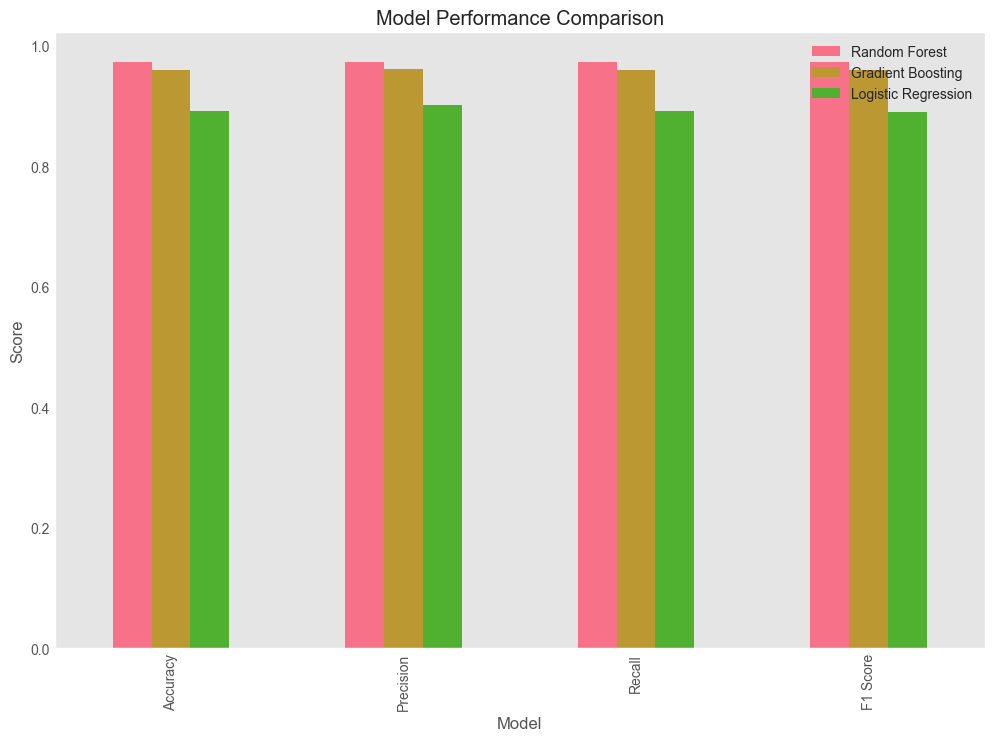

In [173]:
# Plot results for visual comparison
results_df.plot(kind='bar', figsize=(12, 8))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.grid()
plt.show()

In [174]:
#any metrics(accuracy,f1,precision,recall)
best_model_name = results_df.loc['Precision'].idxmax()
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name}")


Best Model: Random Forest


In [175]:
# Generate and plot the confusion matrix
def plot_confusion_matrix (models, x_test, model_name):
    y_pred = models.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix for {model_name} Model")
    plt.show()

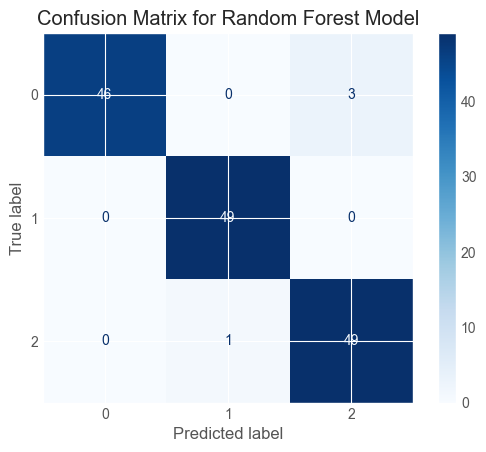

In [176]:
plot_confusion_matrix(models['Random Forest'], x_test, 'Random Forest')

In [177]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        High       1.00      0.92      0.96        49
         Low       0.80      1.00      0.89        49
         Mid       0.90      0.76      0.83        50

    accuracy                           0.89       148
   macro avg       0.90      0.89      0.89       148
weighted avg       0.90      0.89      0.89       148



In [178]:
state_risk = df.groupby('State').agg({
    'Risk_Category': 'first',
    'Total_Crimes': 'mean',
    'Safety_Score': 'mean',
    'Rape': 'mean',
    'K&A': 'mean',
    'DD': 'mean',
    'AoW': 'mean',
    'AoM': 'mean',
    'DV': 'mean',
    'WT': 'mean'
}).round(2)

In [179]:

state_risk = state_risk.sort_values('Safety_Score', ascending=False)

In [180]:
# Top 10 High-Risk States
print(f"\nTop 10 High-Risk States:")
high_risk_states = state_risk[state_risk['Risk_Category'] == 'High'].head(10)
for idx, (state, row) in enumerate(high_risk_states.iterrows(), 1):
    print(f"{idx:2d}. {state:25s} Score: {row['Safety_Score']:10.2f}  Crimes: {row['Total_Crimes']:8.0f}")


Top 10 High-Risk States:
 1. Uttar Pradesh             Score:   26056.90  Crimes:    31903
 2. West Bengal               Score:   19537.08  Crimes:    24164
 3. Madhya Pradesh            Score:   19293.20  Crimes:    23890
 4. Rajasthan                 Score:   18205.05  Crimes:    22093
 5. Assam                     Score:   16727.51  Crimes:    20310
 6. Maharashtra               Score:   16478.35  Crimes:    21100
 7. ANDHRA PRADESH            Score:   14410.44  Crimes:    19108
 8. UTTAR PRADESH             Score:   14190.56  Crimes:    17880
 9. Andhra Pradesh            Score:   13785.72  Crimes:    18186
10. MADHYA PRADESH            Score:   11897.80  Crimes:    15036


C:\Users\HP\AppData\Local\Temp\ipykernel_108768\101413834.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=high_risk_states.reset_index(), x='Safety_Score', y='State', palette='flare')


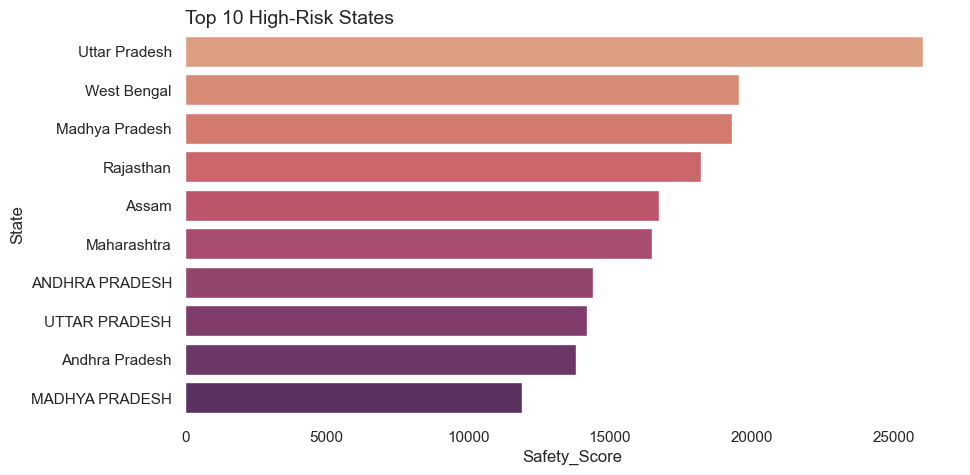

In [184]:

plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

# Plot using 'State' and 'Safety_Score'
ax = sns.barplot(data=high_risk_states.reset_index(), x='Safety_Score', y='State', palette='flare')
plt.title("Top 10 High-Risk States", fontsize=14, loc='left')
sns.despine(left=True, bottom=True)



In [181]:
print(f"\nTop 10 Low-Risk States:")
low_risk_states = state_risk[state_risk['Risk_Category'] == 'Low'].head(10)
for idx, (state, row) in enumerate(low_risk_states.iterrows(), 1):
    print(f"{idx:2d}. {state:25s} Score: {row['Safety_Score']:10.2f}  Crimes: {row['Total_Crimes']:8.0f}")


Top 10 Low-Risk States:
 1. Telangana                 Score:    6176.55  Crimes:     7920
 2. Nagaland                  Score:    3509.32  Crimes:     4570
 3. D&N Haveli                Score:    1630.22  Crimes:     1974
 4. Sikkim                    Score:     530.40  Crimes:      639
 5. Daman & Diu               Score:     497.41  Crimes:      631
 6. Chandigarh                Score:     272.82  Crimes:      329
 7. Arunachal Pradesh         Score:     240.73  Crimes:      288
 8. Goa                       Score:     236.95  Crimes:      297
 9. Meghalaya                 Score:     221.15  Crimes:      255
10. Manipur                   Score:     212.29  Crimes:      250


C:\Users\HP\AppData\Local\Temp\ipykernel_108768\2668703307.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=low_risk_states.reset_index(), x='Safety_Score', y='State', palette='viridis_r')


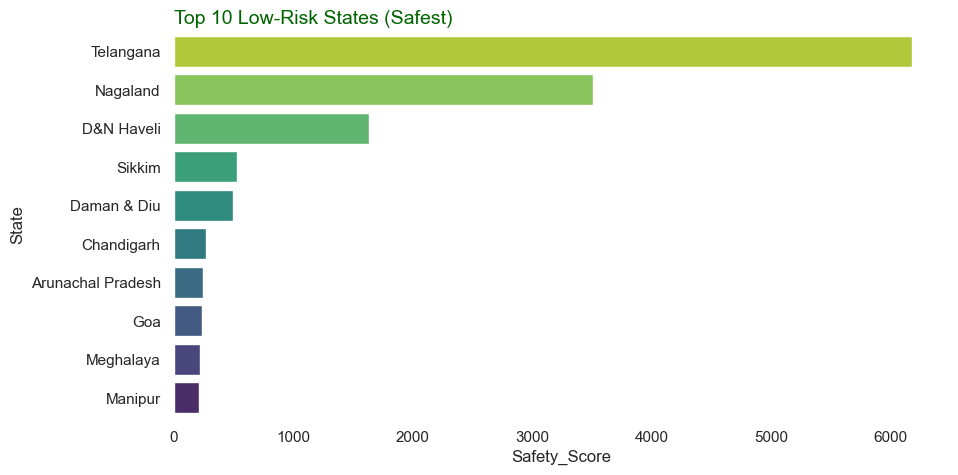

In [185]:

plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

# Plotting Top 10 Low-Risk states with a green palette
ax = sns.barplot(data=low_risk_states.reset_index(), x='Safety_Score', y='State', palette='viridis_r')

# Adding a simple title and cleaning up the edges
plt.title("Top 10 Low-Risk States (Safest)", fontsize=14, loc='left', color='darkgreen')
sns.despine(left=True, bottom=True)
plt.show()